**Setting Up Environment**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

**Uploading Dataset**

In [22]:
from google.colab import files
uploaded = files.upload()

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques (1).zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip", 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Exploratory Data Analysis (EDA)**

Shape of the dataset: (1460, 81)

Data Types and Non-Null Counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null 

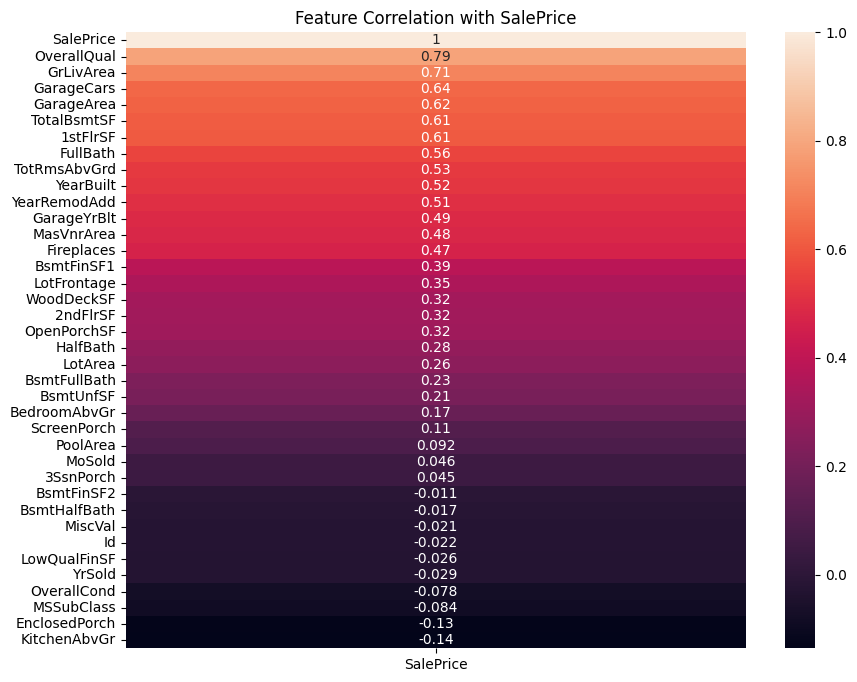

In [ ]:
print("Shape of the dataset:", df.shape)
print("\nData Types and Non-Null Counts:\n")
df.info()
print("\nStatistical Summary:\n")
print(df.describe())

# Visualizing correlation with SalePrice
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True)[['SalePrice']].sort_values('SalePrice', ascending=False), annot=True)
plt.title("Feature Correlation with SalePrice")
plt.show()

**Feature Selection & Preprocessing**

In [ ]:
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
df_model = df[features + ['SalePrice']].dropna()

# Features and target
X = df_model[features]
y = df_model['SalePrice']

**Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train Linear Regression Model**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Predict & Evaluate Model**

In [ ]:
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Model Performance:
Mean Squared Error (MSE): 2806426667.25
R² Score: 0.63


**View Predicted vs Actual Prices**

In [ ]:
comparison_df = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': np.round(y_pred, 2)
})
print("\nComparison of Actual vs Predicted Sale Prices:")
print(comparison_df.head(10))


Comparison of Actual vs Predicted Sale Prices:
   Actual  Predicted
0  154500  113410.67
1  325000  305081.88
2  115000  135904.79
3  159000  205424.68
4  315500  227502.68
5   75500  121157.48
6  311500  205577.98
7  146000  183787.20
8   84500  121157.48
9  135500  147219.22


**Visualize Predictions**

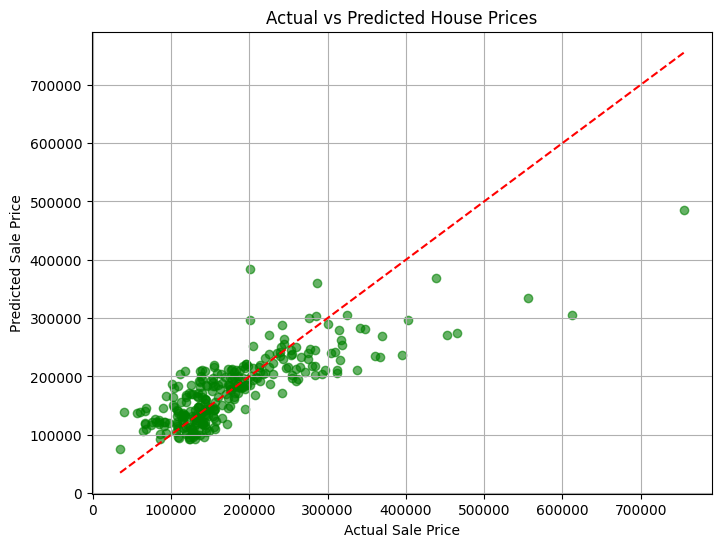

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

**View Model Coefficients**

In [ ]:
coefficients = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print("\nModel Coefficients:")
print(coefficients)


Model Coefficients:
        Feature   Coefficient
0     GrLivArea    104.026307
1  BedroomAbvGr -26655.165357
2      FullBath  30014.324109
